# Tutorial for XC-ID 
(X Chromosome inactivation - IDentifier)

2025-10-23

In [15]:
import os

import numpy as np
import pandas as pd
import xcid

import matplotlib.pyplot as plt

Set up sample information

In [16]:
base_dir = '../data'
os.chdir(base_dir)
chromosome = 'X' # indicate right chromosome

Provide paths for all input files

In [17]:
# provide bams in a list (can provide multiple files)
# make sure to index the bams (.bai files should be in the same directory as the bam files)
bams = ['WASP_X.bam']
# vcf files should be provided in a list
vcf_files = ['variants.vcf']

In [25]:
bams = ['/inkwell04/jlh/my_hapcall/encode_mouse_cross/ENCSR224RWH/WASP_out/WASP_Aligned.sortedByCoord.out.bam']
vcf_files = ['/inkwell04/jlh/my_hapcall/encode_mouse_cross/ENCSR224RWH/vcfs/variants_filtered.vcf']

## Run the full pipeline

In [26]:
xc = xcid.XCID(
    vcf_files=vcf_files,
    bam_files=bams,
    #cells_file='barcodes.txt', # optionally provide a file with cell barcodes
    chromosome=chromosome,
    rand_seed=206,
)

In [27]:
results = xc.run_all()
results.head(10)

1. Loading data and constructing count matrices...
40178 SNPs loaded from X
No filtered cells file provided, all cells will be processed.
Loaded 29696 SNP positions with coverage.
Loaded 30313 cells with informative reads.
Filtering SNPs based on minimum coverage=5, MAF=0.1
Final SNPs to phase: 19446
Remaining informative cells: 15244 out of 30313.
2. Assigning haplotypes via simulated annealing...
Running simulated annealing with 1 initializations, 388920 max iterations.
Initial temperature: 19446000, cooling rate: 0.999.
Iteration 0: cost=[-60547.]
Current temperature: 19446000.0
Iteration 97230: cost=[-489485.]
Current temperature: 0.0
Iteration 194460: cost=[-495405.]
Current temperature: 0.0
Iteration 291690: cost=[-495405.]
Current temperature: 0.0
Best cost found after 388919 iterations: -495405.0. Initial cost: -60535.0.
3. Estimating confidence via bootstrapping...
Performing 100 bootstraps to determine cell confidence...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:  9.8min remaining:  1.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 11.0min finished


4. Compiling results table...
Done!


,cell_id,score,p_value,p_adj,XCI_status
0,CTAATAGTCATTGACA,-4.189825,7.888609e-31,1.446403e-30,X1
1,CTGATCACAAGTGAAC,-6.189825,7.888609e-31,1.446403e-30,X1
2,AGGTTACTCTCCTCAA,-4.415037,7.888609e-31,1.446403e-30,X1
3,TACGGATTCACCAATA,-6.523562,7.888609e-31,1.446403e-30,X1
4,TGCGCGAGTGGACCTG,-5.321928,7.888609e-31,1.446403e-30,X1
5,AATGTCATCGTTACTT,-4.169925,7.888609e-31,1.446403e-30,X1
6,TCTCCTCGTACTAAAC,5.523562,7.888609e-31,1.446403e-30,X0
7,-,-0.965047,7.888609e-31,1.446403e-30,X1
8,TAATCCGCACTGACCG,-3.754888,7.888609e-31,1.446403e-30,X1
9,CCAAGGCTCTCAATAG,0.517848,3.984536e-27,6.970424e-27,X0


In [28]:
print(results['XCI_status'].value_counts())
conf = results.loc[results['XCI_status'] != 'unknown', :]
print(conf.shape[0], 'confident cells detected out of ', results.shape[0], 'total cells.')

XCI_status
X1         8638
X0         4142
unknown    2464
Name: count, dtype: int64
12780 confident cells detected out of  15244 total cells.


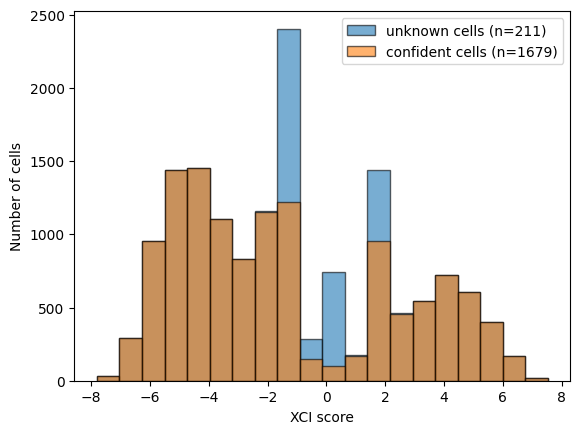

In [29]:
results['score'].hist(bins=20, label='unknown cells (n=211)', 
                      alpha=0.6, edgecolor='black', linewidth=1)
conf['score'].hist(bins=20, label='confident cells (n=1679)', 
                   alpha=0.6, edgecolor='black', linewidth=1)
plt.xlabel('XCI score')
plt.ylabel('Number of cells')
plt.grid(None)
plt.legend()
plt.show()

In [22]:
os.makedirs('results', exist_ok=True)
results.to_csv('results/results.tsv', sep='\t', index=False)

In [23]:
escape_table = xc.escape_table(min_cells=2)
escape_table.head(10)

,position,n_escape_cells,active_counts,inactive_counts
2,7789243,28,475,92
149,94979187,3,53,75
55,60226430,3,152,6
1,7686506,2,38,27
27,55552722,2,83,4


In [24]:
escape_table.to_csv('results/escape_table.tsv', sep='\t', index=False)